In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [7]:
df = pd.read_csv('data.csv ')

In [8]:
print(df.columns.tolist())

['problem_log_id', 'skill', 'problem_id', 'user_id', 'assignment_id', 'assistment_id', 'start_time', 'end_time', 'problem_type', 'original', 'correct', 'bottom_hint', 'hint_count', 'actions', 'attempt_count', 'ms_first_response', 'tutor_mode', 'sequence_id', 'student_class_id', 'position', 'type', 'base_sequence_id', 'skill_id', 'teacher_id', 'school_id', 'overlap_time', 'template_id', 'answer_id', 'answer_text', 'first_action', 'problemlogid', 'Average_confidence(FRUSTRATED)', 'Average_confidence(CONFUSED)', 'Average_confidence(CONCENTRATING)', 'Average_confidence(BORED)']


In [9]:
problem_type_Name = df['problem_type'].unique()
print(f"{problem_type_Name}")

['choose_1' 'algebra' 'fill_in_1' 'rank' 'choose_n' 'open_response']


In [10]:
print(df.iloc[:, 1])

0                                           NaN
1                                      Rounding
2          Multiplication and Division Integers
3                                    Proportion
4                                           NaN
                           ...                 
6123265                                     NaN
6123266                                     NaN
6123267       Addition and Subtraction Integers
6123268                                     NaN
6123269                                     NaN
Name: skill, Length: 6123270, dtype: object


In [11]:
print(df.head)

<bound method NDFrame.head of          problem_log_id                                 skill  problem_id  \
0             137792159                                   NaN      557460   
1             138083797                              Rounding      365981   
2             142332619  Multiplication and Division Integers      426415   
3             145939397                            Proportion       86686   
4             137111284                                   NaN      399669   
...                 ...                                   ...         ...   
6123265       146114936                                   NaN      330756   
6123266       146131268                                   NaN      765964   
6123267       146118011     Addition and Subtraction Integers       84891   
6123268       146118739                                   NaN      543973   
6123269       146122458                                   NaN      136311   

         user_id  assignment_id  assistment_i

In [12]:
# 1. Convert the time columns, telling Pandas to handle mixed formats/microseconds
df['start_time'] = pd.to_datetime(df['start_time'], format='mixed')
df['end_time'] = pd.to_datetime(df['end_time'], format='mixed')

In [13]:
df['session_duration'] = (df['end_time'] - df['start_time']).dt.total_seconds()

In [14]:
print(df['session_duration'].max())

26084889.758


### remove minus value from session_duration

In [16]:
print(len(df[df['session_duration'] < 0]))

727


In [17]:
# 1. See exactly how many corrupted rows we are dealing with
negative_count = len(df[df['session_duration'] < 0])
print(f"Found {negative_count} rows with negative time. Deleting them...")

# 2. THE FIX: Overwrite the dataframe, keeping ONLY rows where time >= 0
df = df[df['session_duration'] >= 0].reset_index(drop=True)

# 3. Verify the fix worked
print("New minimum session duration:", df['session_duration'].min())

Found 727 rows with negative time. Deleting them...
New minimum session duration: 0.012159


### remove minus value from ms_first_response

In [19]:
print(len(df[df['ms_first_response']< 0]))

6


In [20]:
# 1. See exactly how many corrupted rows we are dealing with
negative_count = len(df[df['ms_first_response'] < 0])
print(f"Found {negative_count} rows with negative time. Deleting them...")

# 2. THE FIX: Overwrite the dataframe, keeping ONLY rows where time >= 0
df = df[df['ms_first_response'] >= 0].reset_index(drop=True)

# 3. Verify the fix worked
print("New minimum ms first response:", df['ms_first_response'].min())

Found 6 rows with negative time. Deleting them...
New minimum ms first response: 3


In [21]:
print(df['session_duration'].max())

26084889.758


In [22]:
print(df['ms_first_response'].max())

345055238


In [23]:
print(df['ms_first_response'].min())

3


In [25]:
df['is_scaffold'] = (df['original'] == 0).astype(int)

# Warning  !!

In [27]:
# 1. Take a 10% sample of your original data to prevent RAM crashes
# (Assuming 'df' is my main dataframe from earlier)
print(f"Original dataset size: {len(df)} rows")

Original dataset size: 6122537 rows


In [28]:
df_sampled = df.sample(frac=0.1, random_state=42).reset_index(drop=True)
print(f"Working with a sample of {len(df_sampled)} rows to build the model.")

Working with a sample of 612254 rows to build the model.


In [29]:
missing_data = df_sampled.isnull().sum()

### treate for missing value and selecte most effective data colums

In [31]:
print(f"Final Missing Values count: {df_sampled.isnull().sum()}")



Final Missing Values count: problem_log_id                            0
skill                                349493
problem_id                                0
user_id                                   0
assignment_id                             0
assistment_id                             0
start_time                                0
end_time                                  0
problem_type                              0
original                                  0
correct                                   0
bottom_hint                            5889
hint_count                                0
actions                                   0
attempt_count                             0
ms_first_response                         0
tutor_mode                                0
sequence_id                               0
student_class_id                          0
position                                  0
type                                      0
base_sequence_id                          0
skil

In [32]:
print(len(missing_data))

37


In [33]:
# 2. Define the exact feature list (CRITICAL: 'actions' is completely removed)
final_columns = [
    'skill', 
    'correct', 
    'attempt_count',
    'hint_count',
    'bottom_hint',
    'ms_first_response',
    'first_action',
    'session_duration',
    'is_scaffold',
    'Average_confidence(FRUSTRATED)',
    'Average_confidence(CONFUSED)',
    'Average_confidence(CONCENTRATING)',
    'Average_confidence(BORED)',
    'problem_type'
]

In [34]:
# Create the final dataframe 
df_final = df_sampled[final_columns].copy()

In [35]:
print (len(df_final))

612254


In [36]:
print(df_final.iloc[:, 6])

0         0
1         0
2         0
3         0
4         0
         ..
612249    0
612250    0
612251    1
612252    0
612253    0
Name: first_action, Length: 612254, dtype: int64


In [37]:
missing_data1 = df_final.isnull().sum()

In [38]:
print(len(missing_data1))

14


In [39]:
print(f"Final Missing Values count: {df_final.isnull().sum()}")


Final Missing Values count: skill                                349493
correct                                   0
attempt_count                             0
hint_count                                0
bottom_hint                            5889
ms_first_response                         0
first_action                              0
session_duration                          0
is_scaffold                               0
Average_confidence(FRUSTRATED)            0
Average_confidence(CONFUSED)              0
Average_confidence(CONCENTRATING)         0
Average_confidence(BORED)                 0
problem_type                              0
dtype: int64


In [40]:
print(f"Final Missing Values count: {df_final.isnull().sum().sum()}")


Final Missing Values count: 355382


In [41]:
df_final = df_final.dropna(subset=['skill']).reset_index(drop=True)

In [42]:
print(f"Final Missing Values count: {df_final.isnull().sum()}")

Final Missing Values count: skill                                   0
correct                                 0
attempt_count                           0
hint_count                              0
bottom_hint                          4096
ms_first_response                       0
first_action                            0
session_duration                        0
is_scaffold                             0
Average_confidence(FRUSTRATED)          0
Average_confidence(CONFUSED)            0
Average_confidence(CONCENTRATING)       0
Average_confidence(BORED)               0
problem_type                            0
dtype: int64


In [43]:
df_final['bottom_hint'] = df_final['bottom_hint'].fillna(0)

In [44]:
print(f"Final Missing Values count: {df_final.isnull().sum()}")

Final Missing Values count: skill                                0
correct                              0
attempt_count                        0
hint_count                           0
bottom_hint                          0
ms_first_response                    0
first_action                         0
session_duration                     0
is_scaffold                          0
Average_confidence(FRUSTRATED)       0
Average_confidence(CONFUSED)         0
Average_confidence(CONCENTRATING)    0
Average_confidence(BORED)            0
problem_type                         0
dtype: int64


### check the range and data TYPES

In [46]:
print(df_final['session_duration'])



0          99.966
1          13.872
2          26.217
3          42.676
4           7.146
           ...   
262756     42.738
262757     18.095
262758    151.527
262759     49.205
262760    112.297
Name: session_duration, Length: 262761, dtype: float64


In [47]:
print(df_final['session_duration'].mean())

9040.287228288404


In [48]:
print(df_final['ms_first_response'].max())

103432739


In [49]:
print(df_final['ms_first_response'].min())

253


### "--- CAPPING EXTREME OUTLIERS ---"

In [51]:
upper_limit_session = df_final['session_duration'].quantile(0.99)
print(f"99% of students finished in under {upper_limit_session:.2f} seconds.")

99% of students finished in under 1207.25 seconds.


In [52]:
# 2. Cap the extreme values for session_duration
df_final['session_duration'] = np.where (df_final['session_duration'] > upper_limit_session, upper_limit_session, df_final['session_duration'])



In [53]:
# 3. Let's also protect ms_first_response while we are at it
upper_limit_ms = df_final['ms_first_response'].quantile(0.99)
print(f"99% of students finished in under {upper_limit_ms:.2f} ")
df_final['ms_first_response'] = np.where(df_final['ms_first_response'] > upper_limit_ms, upper_limit_ms, df_final['ms_first_response'])

99% of students finished in under 381409.40 


In [54]:
print(f"New Capped Max for Session Duration: {df_final['session_duration'].max():.2f}")
print(f"New Realistic Mean for Session Duration: {df_final['session_duration'].mean():.2f}")

New Capped Max for Session Duration: 1207.25
New Realistic Mean for Session Duration: 76.22


In [55]:
print(f"New Capped Max for ms first response: {df_final['ms_first_response'].max():.2f}")
print(f"New Realistic Mean for ms first response: {df_final['ms_first_response'].mean():.2f}")

New Capped Max for ms first response: 381409.40
New Realistic Mean for ms first response: 52347.77


In [56]:
print(df_final.iloc[0:5, :])

                                 skill  correct  attempt_count  hint_count  \
0   Addition and Subtraction Fractions      1.0              1           0   
1    Addition and Subtraction Integers      1.0              1           0   
2                   Divisibility Rules      1.0              1           0   
3  Equation Solving Two or Fewer Steps      1.0              1           0   
4                            Exponents      1.0              1           0   

   bottom_hint  ms_first_response  first_action  session_duration  \
0          0.0            99954.0             0            99.966   
1          0.0            13856.0             0            13.872   
2          0.0            26205.0             0            26.217   
3          0.0            42661.0             0            42.676   
4          0.0             7133.0             0             7.146   

   is_scaffold  Average_confidence(FRUSTRATED)  Average_confidence(CONFUSED)  \
0            0                      

### select the train feature and lable   from the dataset 

In [58]:
# 3. Prevent Data Leakage
Y = df_final['correct'].values           #label
X_df = df_final.drop(columns=['correct'])#features

In [59]:
print(df_final['problem_type'])
print(df_final['first_action'])
print(df_final['skill'])




0           algebra
1           algebra
2           algebra
3           algebra
4           algebra
            ...    
262756      algebra
262757    fill_in_1
262758      algebra
262759      algebra
262760      algebra
Name: problem_type, Length: 262761, dtype: object
0         0
1         0
2         0
3         0
4         0
         ..
262756    0
262757    0
262758    0
262759    0
262760    1
Name: first_action, Length: 262761, dtype: int64
0          Addition and Subtraction Fractions
1           Addition and Subtraction Integers
2                          Divisibility Rules
3         Equation Solving Two or Fewer Steps
4                                   Exponents
                         ...                 
262756               Multiplication Fractions
262757                         Point Plotting
262758                           Circle Graph
262759                 Perimeter of a Polygon
262760                             Proportion
Name: skill, Length: 262761, dtype: object


In [60]:
total_skill = df_final['skill'].nunique()

In [61]:
print(f"{total_skill}")

198


In [62]:
total_scaffold = df_final['is_scaffold'].unique()

In [63]:
print(f"{total_scaffold}")

[0 1]


 ### here you can see data 

In [65]:
# using that code you can see all 198 skill type
# skill_names = df_final['skill'].unique()
# print(skill_names)

In [66]:
total_faNames = df_final['first_action'].unique()
print(f"{total_faNames}")

[0 1 2]


In [67]:
total_fa = df_final['first_action'].nunique()

In [68]:
print(f"{total_fa}")

3


In [69]:
problem_type_Names = df_final['problem_type'].unique()
print(f"{problem_type_Names}")

['algebra' 'choose_1' 'fill_in_1' 'choose_n' 'rank' 'open_response']


In [70]:
total_problem_type = df_final['problem_type'].nunique()

In [71]:
print(f"{total_problem_type}")

6


### Haddleing Categorical Data (using One hot Encoding)

In [73]:
# 4. Handle Categorical Data (One-Hot Encoding)
categorical_cols = ['skill', 'problem_type', 'first_action']
X_encoded = pd.get_dummies(X_df, columns=categorical_cols, drop_first=True)

In [74]:
#4. Strategy for other Categorical Data
categorical_cols = ['problem_type', 'first_action']
X_df[categorical_cols] = X_df[categorical_cols].fillna('Unknown')

In [75]:
print(f"Final Missing Values count: {X_df.isnull().sum().sum()}")

Final Missing Values count: 0


In [76]:
# 5. Feature Scaling (No text columns in here!)
numerical_cols = [
    'attempt_count', 
    'hint_count', 
    'bottom_hint', 
    'ms_first_response', 
    'session_duration',
    'Average_confidence(FRUSTRATED)',
    'Average_confidence(CONFUSED)',
    'Average_confidence(CONCENTRATING)',
    'Average_confidence(BORED)'
]

In [77]:
scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

### succesfully sacller 

In [79]:
print (X_encoded['session_duration'].max())

7.758346528396595


In [80]:
print (X_encoded['session_duration'].min())

-0.522739726309361


In [81]:
# 6. Memory Optimization: Downcast to 32-bit floats BEFORE converting to NumPy
# This forces everything to be a mathematical number and saves massive amounts of RAM
X_encoded = X_encoded.astype('float32')

# 7. Convert to final NumPy array
X = X_encoded.values


print(f"Shape of Input Features (X): {X.shape}")
print(f"Shape of Target Variable (Y): {Y.shape}")

Shape of Input Features (X): (262761, 214)
Shape of Target Variable (Y): (262761,)


In [82]:
## print(X_encoded.iloc[0:5, :])

### here you can see all colums in the dataset

In [84]:
###print(X_encoded.columns.tolist())

In [85]:
print(df_final.columns.tolist())

['skill', 'correct', 'attempt_count', 'hint_count', 'bottom_hint', 'ms_first_response', 'first_action', 'session_duration', 'is_scaffold', 'Average_confidence(FRUSTRATED)', 'Average_confidence(CONFUSED)', 'Average_confidence(CONCENTRATING)', 'Average_confidence(BORED)', 'problem_type']


In [86]:
print(X_encoded.iloc[0:5, :])

   attempt_count  hint_count  bottom_hint  ms_first_response  \
0      -0.316205    -0.37338    -0.373148           0.710522   
1      -0.316205    -0.37338    -0.373148          -0.574489   
2      -0.316205    -0.37338    -0.373148          -0.390180   
3      -0.316205    -0.37338    -0.373148          -0.144575   
4      -0.316205    -0.37338    -0.373148          -0.674829   

   session_duration  is_scaffold  Average_confidence(FRUSTRATED)  \
0          0.162891          0.0                       -0.257491   
1         -0.427673          0.0                       -0.257491   
2         -0.342992          0.0                       -0.257491   
3         -0.230091          0.0                       -0.257491   
4         -0.473810          0.0                       -0.257491   

   Average_confidence(CONFUSED)  Average_confidence(CONCENTRATING)  \
0                     -0.235726                          -1.874192   
1                     -0.235726                          -1.874192

# training Part 

In [88]:
import numpy as np

unique, counts = np.unique(Y, return_counts=True)
for val, cnt in zip(unique, counts):
    print(f"Class {val}: {cnt} samples")

Class 0.0: 79958 samples
Class 0.25: 2 samples
Class 0.5: 4 samples
Class 0.6: 5 samples
Class 0.65: 1 samples
Class 0.75: 15 samples
Class 1.0: 182776 samples


In [89]:
Y_clean = (Y > 0).astype(np.float32)

unique, counts = np.unique(Y_clean, return_counts=True)
for val, cnt in zip(unique, counts):
    print(f"Class {val}: {cnt} samples")

Class 0.0: 79958 samples
Class 1.0: 182803 samples


In [90]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, Y_clean, test_size=0.10, random_state=42, stratify=Y_clean)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (210234, 214)
Val:   (26250, 214)
Test:  (26277, 214)


###  Check what's still object


In [92]:
import numpy as np

print("X_train dtypes:")
print(X_train.dtypes)
print("\nObject columns:", X_train.select_dtypes(include='object').columns.tolist())

X_train dtypes:
attempt_count                 float32
hint_count                    float32
bottom_hint                   float32
ms_first_response             float32
session_duration              float32
                               ...   
problem_type_fill_in_1        float32
problem_type_open_response    float32
problem_type_rank             float32
first_action_1                float32
first_action_2                float32
Length: 214, dtype: object

Object columns: []


In [93]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

#model = Sequential([
#     Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
#     Dropout(0.3),
#     Dense(128, activation='relu'),
#     Dropout(0.3),
#     Dense(64, activation='relu'),
#     Dropout(0.2),
#     Dense(32, activation='relu'),
#     Dense(1, activation='sigmoid')
# ])

# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# # history = model.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     epochs=100,
#     batch_size=32,
#     callbacks=[early_stop],
#     verbose=1
# )

IndentationError: unexpected indent (1135558317.py, line 6)

![this is neural Network  ](grapical_design.png)

![this  is neural network with dropout](With_dropout_Layers.png)

In [113]:
#Confirm the class imbalance
import numpy as np
zeros = np.sum(Y_clean == 0)
ones  = np.sum(Y_clean == 1)
print(f"Class 0 (incorrect): {zeros} ({zeros/len(Y_clean)*100:.1f}%)")
print(f"Class 1 (correct):   {ones}  ({ones/len(Y_clean)*100:.1f}%)")

Class 0 (incorrect): 79958 (30.4%)
Class 1 (correct):   182803  (69.6%)


####  according to abvoe result imbalance lables 70/30 mild class imbalance.
###   Elegant Fix: Class Weights

In [116]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Class weights to penalize missing the minority class
total = len(y_train)
n_zeros = np.sum(y_train == 0)
n_ones  = np.sum(y_train == 1)

class_weight = {
    0: total / (2 * n_zeros),
    1: total / (2 * n_ones)
}
print("Class weights:", class_weight)

#  BatchNormalization
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Class weights: {0: 1.6431206427611218, 1: 0.7186995760973609}


C:\Users\ASUS\anaconda3\envs\ocr-numpy1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │          55,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 98,305 (384.00 KB)

 Trainable params: 98,305 (384.00 KB)

 Non-trainable params: 0 (0.00 B)

In [118]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9255 - loss: 0.2810 - val_accuracy: 0.9357 - val_loss: 0.2191
Epoch 2/100
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9340 - loss: 0.2544 - val_accuracy: 0.9388 - val_loss: 0.2226
Epoch 3/100
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9365 - loss: 0.2457 - val_accuracy: 0.9388 - val_loss: 0.2119
Epoch 4/100
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9376 - loss: 0.2419 - val_accuracy: 0.9382 - val_loss: 0.2237
Epoch 5/100
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9381 - loss: 0.2396 - val_accuracy: 0.9382 - val_loss: 0.2100
Epoch 6/100
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9382 - loss: 0.2378 - val_accuracy: 0.9394 - val_loss: 0.2128
Epoch 7/100
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9382 - loss: 0.2365 - val_accuracy: 0.9402 - val_loss: 0.2192
Epoch 8/100
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9386 - loss: 0

### save the model as keras

In [121]:

model.save("student_success_model.keras")

print("Model successfully saved to disk as 'student_success_model.keras'!")

Model successfully saved to disk as 'student_success_model.keras'!


### load thhe AI model as back up( Wake the AI back up)

In [124]:
from tensorflow.keras.models import load_model


saved_ai = load_model("student_success_model.keras")

print("Model loaded and ready to make predictions!")

Model loaded and ready to make predictions!


### save use for web app

In [127]:
import joblib


joblib.dump(scaler, 'student_scaler.pkl')

['student_scaler.pkl']

### Testing for Unseen Data  

In [130]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"\nFinal True Accuracy on Unseen Data: {test_accuracy * 100:.2f}%")

822/822 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - accuracy: 0.9409 - loss: 0.2030

Final True Accuracy on Unseen Data: 94.09%


### Test for the  INDIVIDUAL PREDICTIONS

In [133]:
import numpy as np

print("\n--- PEEKING AT INDIVIDUAL PREDICTIONS ---")

# 1. Have the AI predict the probabilities for the first 10 students in the test set
raw_predictions = model.predict(X_test[:10])

# 2. Convert those probabilities (e.g., 0.85) into strict 1s or 0s
binary_predictions = (raw_predictions > 0.5).astype(int).flatten()


actual_answers = y_test[:10].to_numpy() if hasattr(y_test, 'to_numpy') else np.array(y_test[:10])


for i in range(10):
    pred   = binary_predictions[i]
    actual = actual_answers[i]
    
    status = "✅ CORRECT" if pred == actual else "❌ WRONG"
    
    print(f"Student {i+1} | AI Guessed: {pred} | Actual Grade: {actual} | {status}")


--- PEEKING AT INDIVIDUAL PREDICTIONS ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Student 1 | AI Guessed: 1 | Actual Grade: 1.0 | ✅ CORRECT
Student 2 | AI Guessed: 0 | Actual Grade: 0.0 | ✅ CORRECT
Student 3 | AI Guessed: 1 | Actual Grade: 0.0 | ❌ WRONG
Student 4 | AI Guessed: 1 | Actual Grade: 1.0 | ✅ CORRECT
Student 5 | AI Guessed: 0 | Actual Grade: 0.0 | ✅ CORRECT
Student 6 | AI Guessed: 1 | Actual Grade: 1.0 | ✅ CORRECT
Student 7 | AI Guessed: 1 | Actual Grade: 1.0 | ✅ CORRECT
Student 8 | AI Guessed: 1 | Actual Grade: 1.0 | ✅ CORRECT
Student 9 | AI Guessed: 0 | Actual Grade: 0.0 | ✅ CORRECT
Student 10 | AI Guessed: 0 | Actual Grade: 0.0 | ✅ CORRECT


In [135]:
print(df_final.iloc[0:5, :])

                                 skill  correct  attempt_count  hint_count  \
0   Addition and Subtraction Fractions      1.0              1           0   
1    Addition and Subtraction Integers      1.0              1           0   
2                   Divisibility Rules      1.0              1           0   
3  Equation Solving Two or Fewer Steps      1.0              1           0   
4                            Exponents      1.0              1           0   

   bottom_hint  ms_first_response  first_action  session_duration  \
0          0.0            99954.0             0            99.966   
1          0.0            13856.0             0            13.872   
2          0.0            26205.0             0            26.217   
3          0.0            42661.0             0            42.676   
4          0.0             7133.0             0             7.146   

   is_scaffold  Average_confidence(FRUSTRATED)  Average_confidence(CONFUSED)  \
0            0                      

### ------------------------------------------------------------------------------------------------------------------------------------

###  Creating a brand new, hypothetical student...

In [139]:
# ✏️ 14 Features exactly matching your dataset schema
new_student_data = {
    # --- CATEGORICAL COLUMNS ---
    'skill': ['Exponents '],                  # E.g., 'Algebra', 'Fractions', etc.
    'problem_type': ['algebra'],   # E.g., 'Multiple Choice', 'Open Response'
    'first_action': [0],                   # You noted this is 0, 1, or 2
    
    # --- NUMERICAL COLUMNS ---
                            
    'attempt_count': [1],                  # Struggled and took 4 attempts
    'hint_count': [0],                     # Asked for 2 hints
    'bottom_hint': [0],                    # Reached the bottom hint (1) or not (0)
    'ms_first_response': [7133.0],          # Took 80 seconds to click something
    'session_duration': [7.146],           # Total time spent
    'is_scaffold': [0],                    # Is this a scaffolding problem? (0 or 1)
    
    # Affective / Confidence Scores (e.g., probability scores from 0.0 to 1.0)
    'Average_confidence(FRUSTRATED)': [0.361323],   # Highly frustrated
    'Average_confidence(CONFUSED)': [0.911765],         # Quite confused
    'Average_confidence(CONCENTRATING)': [0.766925],     # Low concentration
    'Average_confidence(BORED)': [0.00]             # Not bored, just struggling
}

df_new_student = pd.DataFrame(new_student_data)
print("Raw Student Data:")
print(df_new_student)

Raw Student Data:
        skill problem_type  first_action  attempt_count  hint_count  \
0  Exponents       algebra             0              1           0   

   bottom_hint  ms_first_response  session_duration  is_scaffold  \
0            0             7133.0             7.146            0   

   Average_confidence(FRUSTRATED)  Average_confidence(CONFUSED)  \
0                        0.361323                      0.911765   

   Average_confidence(CONCENTRATING)  Average_confidence(BORED)  
0                           0.766925                        0.0  


###  Encoding and aligning the data format...

In [142]:
# First, One-Hot Encode the new student's text/categorical columns
categorical_colums = ['skill', 'problem_type', 'first_action']
new_encoded = pd.get_dummies(df_new_student, columns=categorical_colums)

#4. Strategy for other Categorical Data
categorical_colums = ['problem_type', 'first_action']
X_df[categorical_colums] = X_df[categorical_colums].fillna('Unknown')

# THE MAGIC TRICK: Force this 1 student to have the exact 214 columns your model expects!
# ✏️ We use X_train.columns here because that is the exact blueprint the model learned!
new_encoded = new_encoded.reindex(columns=X_train.columns, fill_value=0)

In [144]:
print(new_encoded)

   attempt_count  hint_count  bottom_hint  ms_first_response  \
0              1           0            0             7133.0   

   session_duration  is_scaffold  Average_confidence(FRUSTRATED)  \
0             7.146            0                        0.361323   

   Average_confidence(CONFUSED)  Average_confidence(CONCENTRATING)  \
0                      0.911765                           0.766925   

   Average_confidence(BORED)  ...  \
0                        0.0  ...   

   skill_Write Linear Equation from Slope and y-intercept  \
0                                                  0        

   skill_Writine Expression from Diagrams  skill_X-Y Graph Reading  \
0                                       0                        0   

   problem_type_choose_1  problem_type_choose_n  problem_type_fill_in_1  \
0                      0                      0                       0   

   problem_type_open_response  problem_type_rank  first_action_1  \
0                           0      

### Scaling the numbers using the saved training logic...

In [147]:
# ✏️ Explicitly list 9 numerical columns
numerical_colums = [
   'attempt_count', 
    'hint_count', 
    'bottom_hint', 
    'ms_first_response', 
    'session_duration',
    'Average_confidence(FRUSTRATED)',
    'Average_confidence(CONFUSED)',
    'Average_confidence(CONCENTRATING)',
    'Average_confidence(BORED)'
]

# Notice we use .transform() here, NOT .fit_transform()! 
# We want to use the exact same math the scaler memorized during training.

new_encoded[numerical_colums] = scaler.transform(new_encoded[numerical_colums])

new_encoded = new_encoded.astype('float32')

In [149]:
print(new_encoded)

   attempt_count  hint_count  bottom_hint  ms_first_response  \
0      -0.316205    -0.37338    -0.373148          -0.674829   

   session_duration  is_scaffold  Average_confidence(FRUSTRATED)  \
0          -0.47381          0.0                       -0.257491   

   Average_confidence(CONFUSED)  Average_confidence(CONCENTRATING)  \
0                      4.454502                           0.530665   

   Average_confidence(BORED)  ...  \
0                  -1.016969  ...   

   skill_Write Linear Equation from Slope and y-intercept  \
0                                                0.0        

   skill_Writine Expression from Diagrams  skill_X-Y Graph Reading  \
0                                     0.0                      0.0   

   problem_type_choose_1  problem_type_choose_n  problem_type_fill_in_1  \
0                    0.0                    0.0                     0.0   

   problem_type_open_response  problem_type_rank  first_action_1  \
0                         0.0      

### Asking the Neural Network for a prediction...

In [152]:

# The model outputs a probability between 0.0 and 1.0
raw_probability = model.predict(new_encoded, verbose=0)[0][0]

# Determine the final class based on the 0.5 threshold
final_prediction = 1 if raw_probability > 0.5 else 0
status = "✅ PASS" if final_prediction == 1 else "❌ FAIL"

# Output the results
print(f"{raw_probability}")
print("="*40)
print(f"AI PROBABILITY SCORE: {raw_probability * 100:.2f}%")
print(f"FINAL PREDICTION:     {status} (Class {final_prediction})")
print("="*40)

0.679485023021698
AI PROBABILITY SCORE: 67.95%
FINAL PREDICTION:     ✅ PASS (Class 1)


### ============================================================================

# Testing the  contribution of each  features

In [154]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [164]:
import shap
import matplotlib.pyplot as plt

1. Preparing data for Global Analysis...
2. Initializing SHAP Explainer...
3. Calculating Global Feature Impacts (This may take 1-2 minutes!)...


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [16:24<00:00,  4.92s/it]

4. Generating Global Explanation Charts...


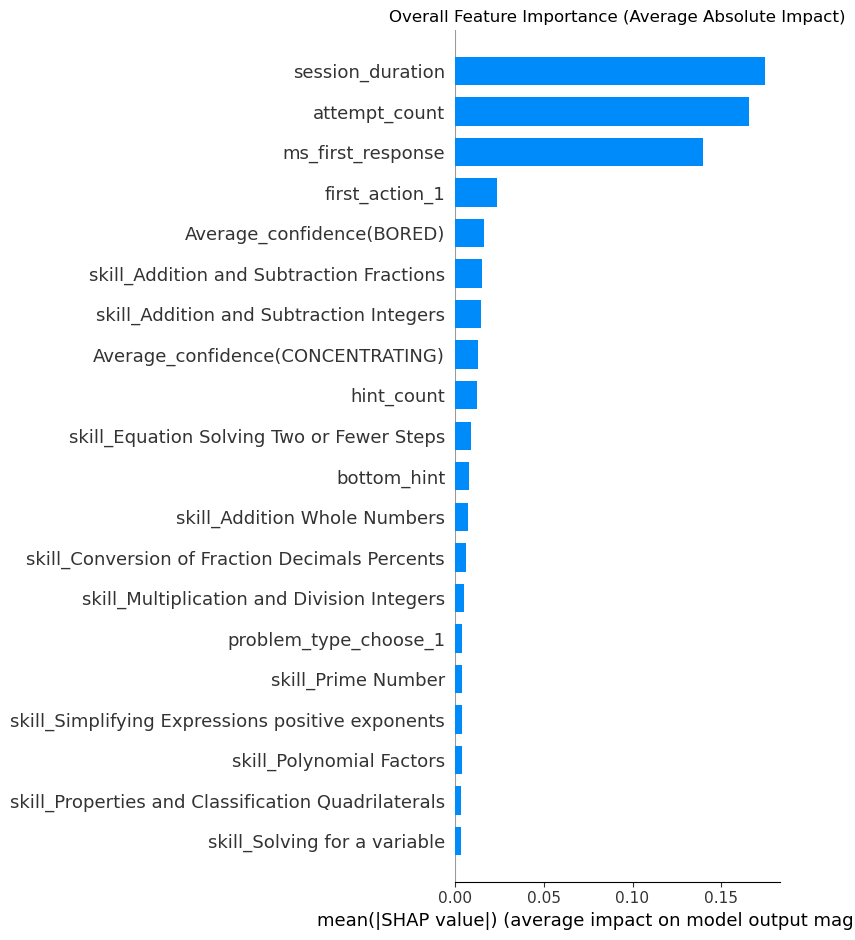

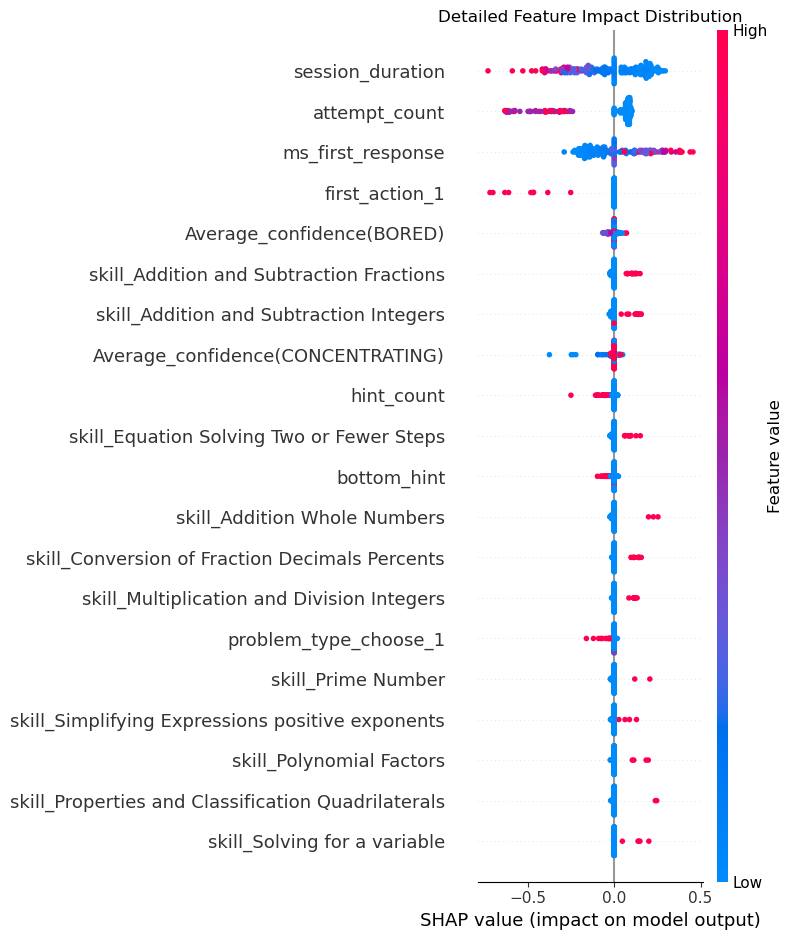


--- TOP 15 MOST IMPORTANT FEATURES OVERALL ---
session_duration                   : Average Impact of 17.43% per prediction
attempt_count                      : Average Impact of 16.55% per prediction
ms_first_response                  : Average Impact of 13.96% per prediction
first_action_1                     : Average Impact of  2.36% per prediction
Average_confidence(BORED)          : Average Impact of  1.62% per prediction
skill_Addition and Subtraction Fractions: Average Impact of  1.50% per prediction
skill_Addition and Subtraction Integers: Average Impact of  1.46% per prediction
Average_confidence(CONCENTRATING)  : Average Impact of  1.28% per prediction
hint_count                         : Average Impact of  1.22% per prediction
skill_Equation Solving Two or Fewer Steps: Average Impact of  0.91% per prediction
bottom_hint                        : Average Impact of  0.79% per prediction
skill_Addition Whole Numbers       : Average Impact of  0.72% per prediction
skill_Convers

In [166]:


print("1. Preparing data for Global Analysis...")

# ⚠️ KernelExplainer is highly accurate but mathematically intense.
# To find the overall trends without waiting hours, we take a random 
# representative sample of 200 students from your Test Set.
X_test_sample = shap.sample(X_test, 200) 

# We give SHAP 100 random training students to establish a "baseline" average
background_data = shap.sample(X_train, 100)

print("2. Initializing SHAP Explainer...")

# We use the same flattening trick here to keep SHAP and Keras perfectly aligned
def predict_flattened(x):
    return model.predict(x, verbose=0).flatten()

explainer = shap.KernelExplainer(predict_flattened, background_data)



# We calculate the precise mathematical impact of every feature for all 200 sampled students
shap_values = explainer.shap_values(X_test_sample)

print("4. Generating Global Explanation Charts...")

# --- CHART 1: THE GLOBAL BAR CHART ---
# This shows the absolute average impact of each feature across all students.
plt.figure(figsize=(10, 6))
plt.title("Overall Feature Importance (Average Absolute Impact)")
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# --- CHART 2: THE BEESWARM PLOT (The Holy Grail of ML Interpretability) ---
# This shows exactly HOW a feature impacts the model (Red = High value, Blue = Low value)
plt.figure(figsize=(10, 6))
plt.title("Detailed Feature Impact Distribution")
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.tight_layout()
plt.show()

print("\n--- TOP 15 MOST IMPORTANT FEATURES OVERALL ---")

# We calculate the average of the absolute SHAP values across all 200 students
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_names = X_test_sample.columns

# Zip them together and sort them from most to least important
global_impacts = sorted(zip(feature_names, mean_abs_shap), key=lambda x: x[1], reverse=True)

# Print the top 15 features and their average percentage impact on ANY given prediction
for feature, impact in global_impacts[:15]:
    percentage_impact = impact * 100
    print(f"{feature: <35}: Average Impact of {percentage_impact:>5.2f}% per prediction")

In [168]:
pip install seaborn

### Distribution of Problem Types

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13696\2674713119.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=X_df, x='problem_type', palette='viridis', order=X_df['problem_type'].value_counts().index)


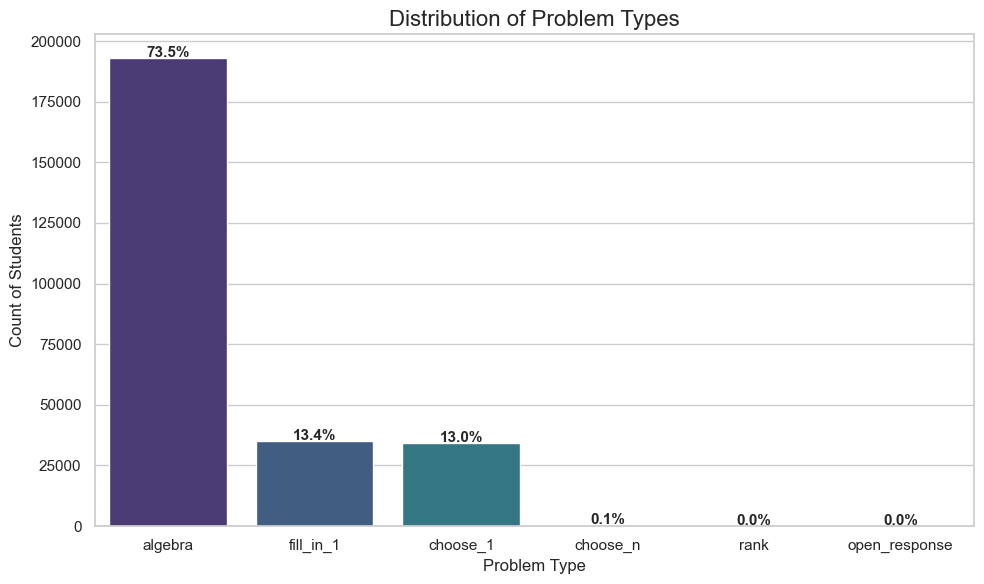


--- DETAILED BREAKDOWN ---
                Count Percentage
problem_type                    
algebra        193090     73.49%
fill_in_1       35088     13.35%
choose_1        34076     12.97%
choose_n          320      0.12%
rank              107      0.04%
open_response      80      0.03%


In [170]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# We use the original DataFrame (X_df) before encoding, 
# because encoded data (One-Hot) breaks categorical bar charts.
counts = X_df['problem_type'].value_counts()
percentages = X_df['problem_type'].value_counts(normalize=True) * 100

ax = sns.countplot(data=X_df, x='problem_type', palette='viridis', order=X_df['problem_type'].value_counts().index)

plt.title('Distribution of Problem Types', fontsize=16)
plt.xlabel('Problem Type', fontsize=12)
plt.ylabel('Count of Students', fontsize=12)

for i, p in enumerate(ax.patches):
    total = len(X_df)
    height = p.get_height()
    percentage = (height / total) * 100
    ax.text(p.get_x() + p.get_width() / 2, height + 500, 
            f'{percentage:.1f}%', ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n--- DETAILED BREAKDOWN ---")
dist_df = pd.DataFrame({'Count': counts, 'Percentage': percentages.map('{:.2f}%'.format)})
print(dist_df)

###  Distribution of skill


C:\Users\ASUS\AppData\Local\Temp\ipykernel_13696\3896858714.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=X_df, x='skill', palette='viridis', order=X_df['skill'].value_counts().index)


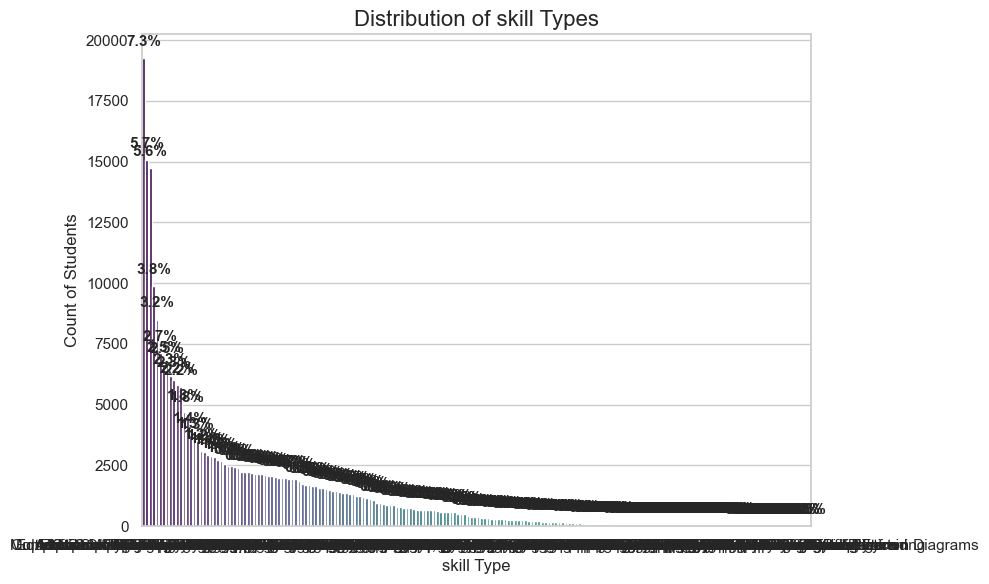


--- DETAILED BREAKDOWN ---
                                                    Count Percentage
skill                                                               
Equation Solving Two or Fewer Steps                 19270      7.33%
Addition and Subtraction Integers                   15072      5.74%
Addition and Subtraction Fractions                  14719      5.60%
Conversion of Fraction Decimals Percents             9867      3.76%
Multiplication and Division Integers                 8500      3.23%
...                                                   ...        ...
Recognizing Expressions or Equations from Diagrams      2      0.00%
Recognize Quadratic Pattern                             2      0.00%
Co-ordinate Points                                      1      0.00%
Combinatorics                                           1      0.00%
Rotational Symmetry                                     1      0.00%

[198 rows x 2 columns]


In [178]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# We use the original DataFrame (X_df) before encoding, 
# because encoded data (One-Hot) breaks categorical bar charts.
counts = X_df['skill'].value_counts()
percentages = X_df['skill'].value_counts(normalize=True) * 100

ax = sns.countplot(data=X_df, x='skill', palette='viridis', order=X_df['skill'].value_counts().index)

plt.title('Distribution of skill Types', fontsize=16)
plt.xlabel('skill Type', fontsize=12)
plt.ylabel('Count of Students', fontsize=12)

for i, p in enumerate(ax.patches):
    total = len(X_df)
    height = p.get_height()
    percentage = (height / total) * 100
    ax.text(p.get_x() + p.get_width() / 2, height + 500, 
            f'{percentage:.1f}%', ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n--- DETAILED BREAKDOWN ---")
dist_df = pd.DataFrame({'Count': counts, 'Percentage': percentages.map('{:.2f}%'.format)})
print(dist_df)

### first_action

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13696\538393459.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=X_df, x='first_action', palette='viridis', order=X_df['first_action'].value_counts().index)


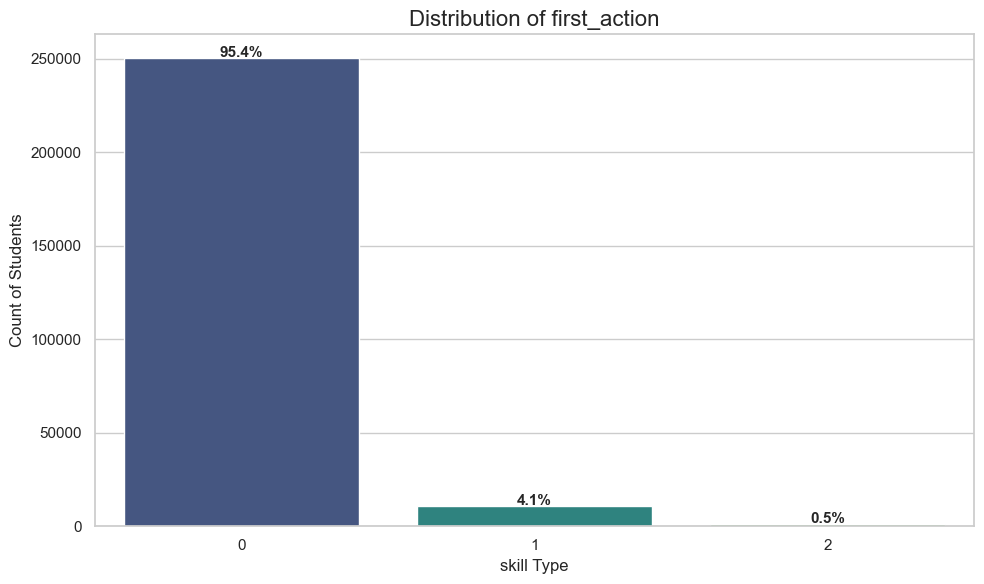


--- DETAILED BREAKDOWN ---
               Count Percentage
first_action                   
0             250568     95.36%
1              10754      4.09%
2               1439      0.55%


In [194]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# We use the original DataFrame (X_df) before encoding, 
# because encoded data (One-Hot) breaks categorical bar charts.
counts = X_df['first_action'].value_counts()
percentages = X_df['first_action'].value_counts(normalize=True) * 100

ax = sns.countplot(data=X_df, x='first_action', palette='viridis', order=X_df['first_action'].value_counts().index)

plt.title('Distribution of first_action', fontsize=16)
plt.xlabel('skill Type', fontsize=12)
plt.ylabel('Count of Students', fontsize=12)

for i, p in enumerate(ax.patches):
    total = len(X_df)
    height = p.get_height()
    percentage = (height / total) * 100
    ax.text(p.get_x() + p.get_width() / 2, height + 500, 
            f'{percentage:.1f}%', ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n--- DETAILED BREAKDOWN ---")
dist_df = pd.DataFrame({'Count': counts, 'Percentage': percentages.map('{:.2f}%'.format)})
print(dist_df)